# 02 — EDA and signal discovery

## What is this notebook for?

EDA is not a competition to make the most charts.

Here it asks one question:

> **Do the legal prediction-time features actually produce different breach rates?**

If two groups have almost the same breach rate, a classifier has little signal to learn from that feature alone.

So EDA becomes a **signal-strength investigation**.

In [1]:
import sys
from pathlib import Path
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(project_root))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
print("Project root:", project_root)

from src.config import data_dir
from src.data.load import load_source_tables, build_master_table
from src.features.base import add_base_features

Project root: /mnt/data/northbridge-sla-breach-work/northbridge-sla-breach


## 1. Rebuild the trusted master table

We reuse project functions so the notebook teaches the idea rather than duplicating production code.

In [2]:
tickets, agents, clients = load_source_tables(data_dir())
master = add_base_features(build_master_table(tickets, agents, clients), sla_due_known=True)
print(f"Rows available: {len(master):,}")
master[["TicketID","PriorityID","CategoryID","Channel","ContractTier","TeamID","SLABreached"]].head()

Rows available: 3,500


,TicketID,PriorityID,CategoryID,Channel,ContractTier,TeamID,SLABreached
0,2179,3,5,Form,Standard,6,0
1,322,3,2,Email,Premium,1,0
2,1331,2,4,Portal,Premium,8,0
3,493,3,1,Email,Standard,1,0
4,2022,3,1,Email,Standard,1,0


## 2. Establish the benchmark

The overall breach rate is the reference line for all subgroup comparisons.

For PR-AUC, the no-skill baseline is approximately the positive-class prevalence.

In [3]:
overall = master["SLABreached"].mean()
print(f"Overall breach prevalence: {overall:.1%}")
print(f"Approximate no-skill PR-AUC baseline: {overall:.3f}")

Overall breach prevalence: 21.5%
Approximate no-skill PR-AUC baseline: 0.215


## 3. Priority

Priority has a real order. If it strongly separates risk, breach rates should move clearly across levels.

In [4]:
priority_table = master.groupby("PriorityID")["SLABreached"].agg(tickets="size", breach_rate="mean").round(3)
priority_table

,tickets,breach_rate
PriorityID,,
1,258,0.287
2,833,0.202
3,1981,0.215
4,428,0.201


Critical tickets breach more often, but the other priorities are close together.

That is **some signal**, not overwhelming separation.

## 4. Intake channel

Phone, Email, Form and Portal may differ in structure and manual effort.

We test the idea rather than assume it.

In [5]:
channel_table = (master.groupby("Channel")["SLABreached"]
                 .agg(tickets="size", breach_rate="mean")
                 .sort_values("breach_rate", ascending=False).round(3))
channel_table

,tickets,breach_rate
Channel,,
Phone,905,0.239
Form,397,0.224
Portal,977,0.208
Email,1221,0.201


Phone has the highest observed rate, but the spread is still narrow.

A better hypothesis may be **Channel × Category** or Channel × historical burden rather than Channel alone.

## 5. Request category

CategoryID is nominal. We ask whether some request families historically breach more often.

In [6]:
category_table = (master.groupby("CategoryID")["SLABreached"]
                  .agg(tickets="size", breach_rate="mean")
                  .sort_values("breach_rate", ascending=False).round(3))
category_table

,tickets,breach_rate
CategoryID,,
5,415,0.243
4,306,0.242
3,706,0.218
2,873,0.206
1,1200,0.204


Categories 4 and 5 show higher observed breach rates.

But this does **not** make CategoryID ordinal. The labels 1–5 do not represent a measured ladder of complexity.

## 6. Contract tier

ContractTier is important operationally, but does it separate breach risk on its own?

In [7]:
master.groupby("ContractTier")["SLABreached"].agg(tickets="size", breach_rate="mean").round(3)

,tickets,breach_rate
ContractTier,,
Enterprise,543,0.208
Premium,1295,0.214
Standard,1662,0.219


The contract-tier rates are close.

This is a good example of a **business-relevant but weak standalone predictor**.

## 7. Team, hub and raw capacity

Each TeamID maps to one Hub, so these fields are nearly the same organisational signal.

We show team breach rate alongside median assigned-agent capacity.

In [8]:
team_table = (master.groupby(["TeamID","Hub"])
              .agg(tickets=("TicketID","size"),
                   breach_rate=("SLABreached","mean"),
                   median_agent_capacity=("DailyCapacity","median")).round(3))
team_table

,,tickets,breach_rate,median_agent_capacity
TeamID,Hub,,,
1,Manchester,1346,0.232,19.000
4,Leeds,601,0.188,23.000
6,Birmingham,736,0.235,20.000
8,Edinburgh,817,0.191,22.000


Team differences exist, but they may reflect different request mixes and workload.

Raw capacity also needs demand context.

## 8. Capacity bands

Does higher DailyCapacity show a simple monotonic reduction in breach?

In [9]:
master["capacity_band"] = pd.cut(master["DailyCapacity"],
    bins=[0,10,15,20,25,100], labels=["≤10","11–15","16–20","21–25","26+"])
master.groupby("capacity_band", observed=False)["SLABreached"].agg(tickets="size", breach_rate="mean").round(3)

,tickets,breach_rate
capacity_band,,
≤10,162,0.167
11–15,481,0.208
16–20,1215,0.221
21–25,1017,0.230
26+,625,0.200


There is no clean “more capacity = fewer breaches” pattern.

That motivates a more meaningful quantity:

> **workload relative to capacity**

Notebook 03 will reconstruct this point-in-time.

## 9. Creation-time regime

After-hours tickets may have less staffed time available, so we compare the simple flags.

In [10]:
master.groupby(["is_weekend","is_after_hours"])["SLABreached"].agg(tickets="size", breach_rate="mean").round(3)

tickets  breach_rate
is_weekend is_after_hours                      
0          0                  1041        0.227
           1                  1424        0.203
1          1                  1035        0.221

The differences remain modest. Simple flags may be too crude.

A better signal may be the actual **SLA window and deadline geometry**.

## 10. One compact visual of separation

The dashed line is overall breach prevalence. The closer each bar remains to that line, the weaker the standalone separation.

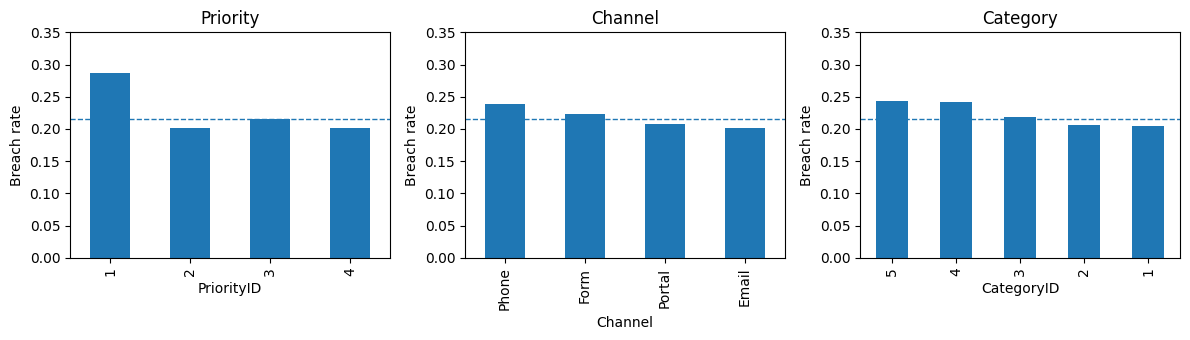

In [11]:
fig, axes = plt.subplots(1,3,figsize=(12,3.5))
priority_table["breach_rate"].plot(kind="bar",ax=axes[0],title="Priority")
channel_table["breach_rate"].plot(kind="bar",ax=axes[1],title="Channel")
category_table["breach_rate"].plot(kind="bar",ax=axes[2],title="Category")
for ax in axes:
    ax.axhline(overall,linestyle="--",linewidth=1)
    ax.set_ylabel("Breach rate"); ax.set_ylim(0,0.35)
plt.tight_layout(); plt.show()

## 11. Turn EDA findings into experiments

| EDA finding | Feature hypothesis |
|---|---|
| raw capacity lacks context | queue/capacity pressure |
| channel differences modest | Category × Channel history |
| Category has some separation | historical resolution burden |
| simple time flags weak | cyclical time + SLA geometry |
| team differences may be workload mix | reconstruct backlog at creation |
| static signal remains weak | add initial-description signals |

EDA succeeds when it produces **testable hypotheses**, not when it produces attractive charts.

**Next:** Notebook 03 builds these signals without time travel.